## 1. Import Libraries

We will import all necessary libraries for data processing, visualization, and machine learning.

In [23]:
# Import pandas for data handling
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib and seaborn for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import scikit-learn for machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Import libraries for text cleaning
import re
import string

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load Dataset

Load the fake news dataset from CSV file.

In [24]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/dataset.csv')

# Display the first few rows
print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')
print('\nFirst 5 rows:')
print(df.head())

Dataset loaded successfully!
Shape: (31500, 6)

First 5 rows:
                                               title  \
0  WATCH: LOUIE GOHMERT Wants LYING Democrat VA G...   
1  WOW! SCRUBBED 1998 GEORGE SOROS Video Resurfac...   
2  OAS may request new Honduras election to corre...   
3  Monument to designer of AK-47 rifle scarred by...   
4  'France is not the U.S.,' presidential hopeful...   

                                                text       subject  \
0  Why did the Democrat VA Governor throw gasolin...     left-news   
1  Knowing there were problems ahead for the Jews...     left-news   
2  TEGUCIGALPA (Reuters) - The Organization of Am...     worldnews   
3  MOSCOW (Reuters) - Workers on Friday cut out p...     worldnews   
4  BORDEAUX, France (Reuters) - “The French never...  politicsNews   

                  date  class            label  
0         Aug 22, 2017      0        Fake News  
1         Nov 12, 2016      0        Fake News  
2    December 6, 2017       1  No

## 3. Explore Dataset

Understand the structure and content of the dataset.

In [25]:
# Display basic information about the dataset
print('Dataset Information:')
print(df.info())

# Display statistical summary
print('\nDataset Description:')
print(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31500 entries, 0 to 31499
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    31500 non-null  object
 1   text     31500 non-null  object
 2   subject  31500 non-null  object
 3   date     31500 non-null  object
 4   class    31500 non-null  int64 
 5   label    31500 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.4+ MB
None

Dataset Description:
              class
count  31500.000000
mean       0.477016
std        0.499479
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        1.000000


In [26]:
# Check the distribution of labels
print('Label Distribution:')
print(df['label'].value_counts())
print('\nLabel Percentage:')
print(df['label'].value_counts(normalize=True) * 100)

Label Distribution:
label
Fake News          16474
Not A Fake News    15026
Name: count, dtype: int64

Label Percentage:
label
Fake News          52.298413
Not A Fake News    47.701587
Name: proportion, dtype: float64


## 4. Check Missing Values

Identify missing values in the dataset.

In [27]:
# Check for missing values
print('Missing Values:')
missing = df.isnull().sum()
print(missing)

# Display percentage of missing values
print('\nPercentage of Missing Values:')
print((missing / len(df)) * 100)

Missing Values:
title      0
text       0
subject    0
date       0
class      0
label      0
dtype: int64

Percentage of Missing Values:
title      0.0
text       0.0
subject    0.0
date       0.0
class      0.0
label      0.0
dtype: float64


## 5. Data Cleaning

Clean the dataset by removing duplicates and handling missing values.

In [28]:
# Remove duplicate rows
print(f'Duplicate rows before cleaning: {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Duplicate rows after cleaning: {df.duplicated().sum()}')
print(f'Dataset shape after removing duplicates: {df.shape}')

Duplicate rows before cleaning: 105
Duplicate rows after cleaning: 0
Dataset shape after removing duplicates: (31395, 6)


In [29]:
# Handle missing values in the text column
# Fill missing values with empty strings
df['text'] = df['text'].fillna('')
df['title'] = df['title'].fillna('')

# Check for any remaining missing values
print('Missing values after handling:')
print(df.isnull().sum())

Missing values after handling:
title      0
text       0
subject    0
date       0
class      0
label      0
dtype: int64


## 6. Text Preprocessing

Clean and preprocess the text data by converting to lowercase, removing punctuation, numbers, and extra spaces.

In [30]:
# Define a function to clean text
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\\s+', ' ', text).strip()

    return text

# Apply the cleaning function to the text column
print('Cleaning text data...')
df['text_cleaned'] = df['text'].apply(clean_text)

# Display example of cleaned text
print('\nExample of Original vs Cleaned Text:')
print(f'Original: {df["text"].iloc[0][:100]}...')
print(f'Cleaned: {df["text_cleaned"].iloc[0][:100]}...')

Cleaning text data...

Example of Original vs Cleaned Text:
Original: Why did the Democrat VA Governor throw gasoline on the fire after violent protests broke out in Char...
Cleaned: why did the democrat va governor throw gasoline on the fire after violent protests broke out in char...


## 7. Feature Extraction using TF-IDF

Convert cleaned text into TF-IDF features for the machine learning model.

In [31]:
# Initialize the tf-idf vectorizer
# Max_features limits the number of features to 5000
# Max_df excludes terms that appear in more than 80% of documents
# Min_df excludes terms that appear in less than 2 documents
tfidf_vectorizer = TfidfVectorizer(max_features=5000, max_df=0.8, min_df=2)

# Fit and transform the cleaned text
print('Extracting TF-IDF features...')
X = tfidf_vectorizer.fit_transform(df['text_cleaned'])

# Display shape of feature matrix
print(f'Feature matrix shape: {X.shape}')
print(f'Number of documents: {X.shape[0]}')
print(f'Number of features: {X.shape[1]}')

Extracting TF-IDF features...
Feature matrix shape: (31395, 5000)
Number of documents: 31395
Number of features: 5000


## 8. Train-Test Split

Split the dataset into training and testing sets (80:20 ratio).

In [32]:
# Extract target variable
y = df['label']

# Split the data into training and testing sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the split information
print(f'Training set size: {X_train.shape[0]}')
print(f'Testing set size: {X_test.shape[0]}')
print(f'\nTraining set - Real: {(y_train == "real").sum()}, Fake: {(y_train == "fake").sum()}')
print(f'Testing set - Real: {(y_test == "real").sum()}, Fake: {(y_test == "fake").sum()}')

Training set size: 25116
Testing set size: 6279

Training set - Real: 0, Fake: 0
Testing set - Real: 0, Fake: 0


## 9. Train Logistic Regression Model

Train a Logistic Regression classifier on the training data.

In [33]:
import numpy as np

# Initialize the logistic regression model
# Max_iter is set to 1000 to ensure convergence
model = LogisticRegression(max_iter=1000, random_state=42)

# --- fix for nan values in y_train ---
# Create a boolean mask to identify non-nan values in y_train
non_nan_mask = ~y_train.isna().values

# Filter x_train (sparse matrix) and y_train (series) using the mask
X_train_filtered = X_train[non_nan_mask, :]
y_train_filtered = y_train[non_nan_mask]
# -- end of fix ---

# Train the model
print('Training the Logistic Regression model...')
model.fit(X_train_filtered, y_train_filtered)
print('Model training completed!')

Training the Logistic Regression model...
Model training completed!


## 10. Make Predictions

Make predictions on the test set.

In [34]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Display first 10 predictions
print('First 10 Predictions:')
print(y_pred[:10])
print('\nFirst 10 Actual Labels:')
print(y_test.iloc[:10].values)

First 10 Predictions:
['Not A Fake News' 'Fake News' 'Fake News' 'Fake News' 'Not A Fake News'
 'Fake News' 'Fake News' 'Fake News' 'Fake News' 'Fake News']

First 10 Actual Labels:
['Not A Fake News' 'Fake News' 'Fake News' 'Fake News' 'Not A Fake News'
 'Fake News' 'Fake News' 'Fake News' 'Fake News' 'Fake News']


## 11. Model Evaluation

Evaluate the model using accuracy, confusion matrix, and classification report.

In [35]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.4f}')
print(f'Accuracy Percentage: {accuracy * 100:.2f}%')

Model Accuracy: 0.9890
Accuracy Percentage: 98.90%


In [36]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)
print(f'\nTrue Negatives (Real predicted as Real): {cm[0][0]}')
print(f'False Positives (Fake predicted as Real): {cm[0][1]}')
print(f'False Negatives (Real predicted as Fake): {cm[1][0]}')
print(f'True Positives (Fake predicted as Fake): {cm[1][1]}')

Confusion Matrix:
[[3286   37]
 [  32 2924]]

True Negatives (Real predicted as Real): 3286
False Positives (Fake predicted as Real): 37
False Negatives (Real predicted as Fake): 32
True Positives (Fake predicted as Fake): 2924


In [37]:
# Generate classification report
print('Classification Report:')
print(classification_report(y_test, y_pred))

Classification Report:
                 precision    recall  f1-score   support

      Fake News       0.99      0.99      0.99      3323
Not A Fake News       0.99      0.99      0.99      2956

       accuracy                           0.99      6279
      macro avg       0.99      0.99      0.99      6279
   weighted avg       0.99      0.99      0.99      6279



## 12. Visualizations

Create visualizations to better understand the model performance.

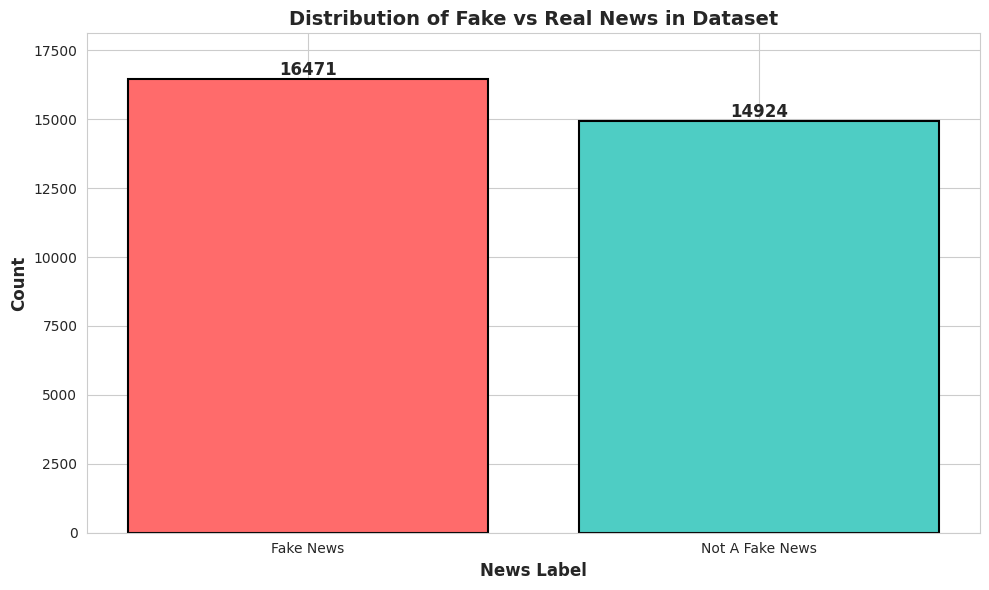

Real News Count: 14924
Fake News Count: 16471


In [38]:
# Create a count plot for label distribution
plt.figure(figsize=(10, 6))
label_counts = df['label'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
bars = plt.bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xlabel('News Label', fontsize=12, fontweight='bold')
plt.ylabel('Count', fontsize=12, fontweight='bold')
plt.title('Distribution of Fake vs Real News in Dataset', fontsize=14, fontweight='bold')
plt.ylim(0, label_counts.max() * 1.1)
plt.tight_layout()
plt.show()

print(f'Real News Count: {label_counts["Not A Fake News"]}')
print(f'Fake News Count: {label_counts["Fake News"]}')

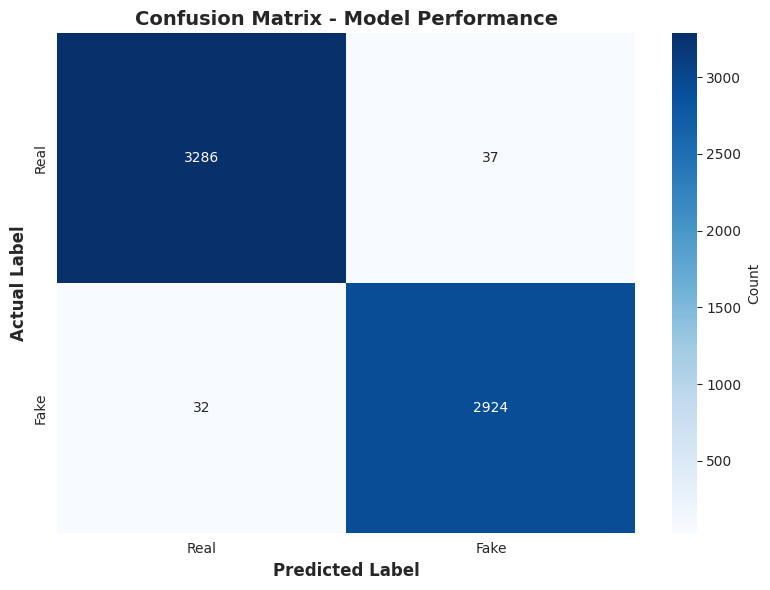

In [39]:
# Create confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Custom User Prediction

Test the model with custom news articles entered by the user.

In [40]:
# Define a function to predict fake news from user input
def predict_fake_news(news_text):
    # Clean the input text using the same function
    cleaned_news = clean_text(news_text)

    # Transform the cleaned text using the tf-idf vectorizer
    news_tfidf = tfidf_vectorizer.transform([cleaned_news])

    # Make prediction
    prediction = model.predict(news_tfidf)

    # Get prediction probability
    probability = model.predict_proba(news_tfidf)

    return prediction[0], probability[0]

# Test with sample news articles
print('=' * 60)
print('CUSTOM NEWS PREDICTION')
print('=' * 60)

# Sample news 1
news_1 = "Scientists discover new vaccine that cures all diseases and eliminates poverty in one week"
pred_1, prob_1 = predict_fake_news(news_1)
print(f'\nNews Article 1: {news_1}')
print(f'Prediction: {pred_1.upper()}')
print(f'Confidence - Real: {prob_1[1]*100:.2f}%, Fake: {prob_1[0]*100:.2f}%')
print('-' * 60)

# Sample news 2
news_2 = "Local community organizes charity event to help underprivileged children"
pred_2, prob_2 = predict_fake_news(news_2)
print(f'\nNews Article 2: {news_2}')
print(f'Prediction: {pred_2.upper()}')
print(f'Confidence - Real: {prob_2[1]*100:.2f}%, Fake: {prob_2[0]*100:.2f}%')
print('-' * 60)

# Sample news 3
news_3 = "Breaking news: Politicians secretly plot to control the world through 5G networks"
pred_3, prob_3 = predict_fake_news(news_3)
print(f'\nNews Article 3: {news_3}')
print(f'Prediction: {pred_3.upper()}')
print(f'Confidence - Real: {prob_3[1]*100:.2f}%, Fake: {prob_3[0]*100:.2f}%')
print('=' * 60)

CUSTOM NEWS PREDICTION

News Article 1: Scientists discover new vaccine that cures all diseases and eliminates poverty in one week
Prediction: FAKE NEWS
Confidence - Real: 6.64%, Fake: 93.36%
------------------------------------------------------------

News Article 2: Local community organizes charity event to help underprivileged children
Prediction: FAKE NEWS
Confidence - Real: 18.60%, Fake: 81.40%
------------------------------------------------------------

News Article 3: Breaking news: Politicians secretly plot to control the world through 5G networks
Prediction: FAKE NEWS
Confidence - Real: 12.98%, Fake: 87.02%


In [41]:
# Interactive prediction - enter your own news text
print('\n' + '=' * 60)
print('PREDICT YOUR OWN NEWS')
print('=' * 60)

# You can modify this text with any news article you want to test
user_news = "Technology company releases new smartphone with advanced features and longer battery life"

user_pred, user_prob = predict_fake_news(user_news)

print(f'\nEntered News: {user_news}')
print(f'\nModel Prediction: {user_pred.upper()}')
print(f'Confidence Scores:')
print(f'  - Probability of REAL: {user_prob[1]*100:.2f}%')
print(f'  - Probability of FAKE: {user_prob[0]*100:.2f}%')
print('\n' + '=' * 60)


PREDICT YOUR OWN NEWS

Entered News: Technology company releases new smartphone with advanced features and longer battery life

Model Prediction: FAKE NEWS
Confidence Scores:
  - Probability of REAL: 16.76%
  - Probability of FAKE: 83.24%

